# CartPole на JAX и Gym

В этом блокноте агент обучается удерживать шест в равновесии как можно дольше.  


- `jax` для параметров, случайных направлений поиска и батчевого выбора действий;
- `gym` для среды `CartPole-v1`;
- `gym.vector.SyncVectorEnv`, чтобы проверять сразу много вариантов политики параллельно.


### Настраиваем окружение

Импортируем локально установленные пакеты и делаем маленький совместимый патч для старого `gym`, чтобы он корректно работал вместе с современным `numpy`


In [1]:
import contextlib
import io
import sys
import time
from pathlib import Path

DEPS_PATH = Path(r"D:\ProjectAI\ai_brief-main\8_reinforcement_learning\.pydeps")
if str(DEPS_PATH) not in sys.path:
    sys.path.insert(0, str(DEPS_PATH))

import numpy as np
if not hasattr(np, "bool8"):
    np.bool8 = np.bool_

with contextlib.redirect_stderr(io.StringIO()):
    import gym

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
np.set_printoptions(precision=3, suppress=True)

GLOBAL_SEED = 0
ENV_NAME = "CartPole-v1"


### Проверяем версии

Ниже быстро убеждаемся, что ноутбук действительно использует локально установленные `jax` и `gym`.


In [2]:
print("Python path prefix:", sys.path[0])
print("jax version:", jax.__version__)
print("gym version:", gym.__version__)
print("jax devices:", jax.devices())


Python path prefix: D:\ProjectAI\ai_brief-main\8_reinforcement_learning\.pydeps
jax version: 0.10.0
gym version: 0.26.2
jax devices: [CpuDevice(id=0)]


## 1. Среда CartPole

Среда возвращает наблюдение из четырех чисел:

- положение тележки;
- скорость тележки;
- угол шеста;
- угловая скорость шеста.

Агент получает награду `1` за каждый шаг, пока эпизод не завершен.  
Максимально возможный возврат в `CartPole-v1` равен `500`.


In [3]:
env = gym.make(ENV_NAME)
obs, info = env.reset(seed=GLOBAL_SEED)
next_obs, reward, terminated, truncated, info = env.step(env.action_space.sample())
env.close()

print("Начальное наблюдение:", obs)
print("Следующее наблюдение:", next_obs)
print("Награда:", reward)
print("terminated:", terminated, "| truncated:", truncated)


Начальное наблюдение: [ 0.014 -0.023 -0.046 -0.048]
Следующее наблюдение: [ 0.013  0.173 -0.047 -0.355]
Награда: 1.0
terminated: False | truncated: False


## 2. Линейная политика
возьмем простую линейную политику: действие определяется знаком скалярного произведения состояния и вектора параметров


In [4]:
@jax.jit
def batch_select_action(obs_batch: jnp.ndarray, params_batch: jnp.ndarray) -> jnp.ndarray:
    scores = jnp.sum(obs_batch * params_batch, axis=1)
    return (scores > 0.0).astype(jnp.int32)


def select_action(obs: np.ndarray, params: jnp.ndarray) -> int:
    obs_batch = jnp.asarray(obs[None, :], dtype=jnp.float32)
    params_batch = jnp.asarray(params[None, :], dtype=jnp.float32)
    return int(batch_select_action(obs_batch, params_batch)[0])


### Быстрая проверка политики

Случайные параметры обычно дают слабую стратегию. Это будет нашим базовым ориентиром.


In [5]:
key = jax.random.PRNGKey(GLOBAL_SEED)
random_params = jax.random.normal(key, shape=(4,), dtype=jnp.float32)
print("Случайные параметры:", np.array(random_params))
print("Действие для текущего состояния:", select_action(obs, random_params))


Случайные параметры: [ 1.623  2.025 -0.434 -0.079]
Действие для текущего состояния: 0


## 3. Цикл агент-среда


In [6]:
def make_vector_env(num_envs: int):
    return gym.vector.SyncVectorEnv([lambda: gym.make(ENV_NAME) for _ in range(num_envs)])


def rollout_batch(params_batch: jnp.ndarray, seeds: np.ndarray) -> np.ndarray:
    num_envs = int(params_batch.shape[0])
    envs = make_vector_env(num_envs)
    obs, _ = envs.reset(seed=list(map(int, seeds)))

    returns = np.zeros(num_envs, dtype=np.float32)
    done = np.zeros(num_envs, dtype=bool)

    while not np.all(done):
        actions = np.array(
            batch_select_action(jnp.asarray(obs, dtype=jnp.float32), params_batch),
            dtype=np.int32,
        )
        next_obs, reward, terminated, truncated, _ = envs.step(actions)
        newly_done = np.logical_or(terminated, truncated)
        active = ~done
        returns[active] += reward[active]
        done = np.logical_or(done, newly_done)
        obs = next_obs

    envs.close()
    return returns


def evaluate_policy(params: jnp.ndarray, episodes: int = 20, seed: int = 0) -> float:
    params = jnp.asarray(params, dtype=jnp.float32)
    params_batch = jnp.repeat(params[None, :], episodes, axis=0)
    seeds = np.arange(seed, seed + episodes)
    returns = rollout_batch(params_batch, seeds)
    return float(np.mean(returns))


### Базовый уровень

Перед обучением измерим, насколько плоха случайная политика в среднем.


In [7]:
baseline_return = evaluate_policy(random_params, episodes=30, seed=1_000)
print(f"Средний возврат случайной политики: {baseline_return:.1f}")


Средний возврат случайной политики: 9.2


## 4. Random Policy Search

Используем тот же класс идей, что и в лабораторной:

1. берем текущие параметры;
2. генерируем случайные направления поиска `delta`;
3. сравниваем `params + noise * delta` и `params - noise * delta`;
4. обновляем параметры в сторону направлений, которые дали лучший возврат.

За один шаг мы проверяем много кандидатных политик сразу, поэтому обучение получается и короче, и стабильнее.


In [8]:
def train_random_policy_search(
    seed: int = 0,
    iterations: int = 45,
    directions: int = 24,
    top_directions: int = 12,
    step_size: float = 0.04,
    noise_scale: float = 0.35,
):
    key = jax.random.PRNGKey(seed)
    key, init_key = jax.random.split(key)

    params = jax.random.normal(init_key, shape=(4,), dtype=jnp.float32) * 0.2
    best_params = params
    best_score = evaluate_policy(best_params, episodes=10, seed=10_000)

    best_history = [best_score]
    current_history = []

    for iteration in range(iterations):
        key, delta_key = jax.random.split(key)
        deltas = jax.random.normal(delta_key, shape=(directions, 4), dtype=jnp.float32)

        params_pos = params + noise_scale * deltas
        params_neg = params - noise_scale * deltas
        candidate_params = jnp.concatenate([params_pos, params_neg], axis=0)

        seeds = np.arange(1_000 * iteration, 1_000 * iteration + 2 * directions)
        candidate_returns = rollout_batch(candidate_params, seeds)
        rewards_pos = candidate_returns[:directions]
        rewards_neg = candidate_returns[directions:]

        scores = np.maximum(rewards_pos, rewards_neg)
        elite_indices = np.argsort(scores)[-top_directions:]

        sigma_r = float(
            np.std(np.concatenate([rewards_pos[elite_indices], rewards_neg[elite_indices]])) + 1e-8
        )

        step = jnp.sum(
            (rewards_pos[elite_indices] - rewards_neg[elite_indices])[:, None] * deltas[elite_indices],
            axis=0,
        )

        params = params + (step_size / (top_directions * sigma_r)) * step

        current_score = evaluate_policy(params, episodes=10, seed=20_000 + 10 * iteration)
        current_history.append(current_score)

        if current_score > best_score:
            best_score = current_score
            best_params = params

        best_history.append(best_score)

        if (iteration + 1) % 5 == 0:
            print(
                f"Итерация {iteration + 1:02d}/{iterations}: "
                f"текущий возврат = {current_score:.1f}, лучший = {best_score:.1f}"
            )

    return {
        "best_params": best_params,
        "best_score": best_score,
        "best_history": np.array(best_history, dtype=np.float32),
        "current_history": np.array(current_history, dtype=np.float32),
    }


## 5. Обучение

Если все идет хорошо, агент уже через несколько десятков итераций должен приблизиться к максимальному возврату `500`.


In [9]:
start = time.time()
result = train_random_policy_search(seed=GLOBAL_SEED)
elapsed = time.time() - start

best_params = result["best_params"]
best_score = float(result["best_score"])

print(f"Обучение завершено за {elapsed:.1f} сек.")
print(f"Лучший средний возврат во время обучения: {best_score:.1f}")
print("Лучшие параметры:", np.array(best_params))


Итерация 05/45: текущий возврат = 79.9, лучший = 79.9


Итерация 10/45: текущий возврат = 184.7, лучший = 184.7


Итерация 15/45: текущий возврат = 417.5, лучший = 417.5


Итерация 20/45: текущий возврат = 500.0, лучший = 500.0


Итерация 25/45: текущий возврат = 500.0, лучший = 500.0


Итерация 30/45: текущий возврат = 500.0, лучший = 500.0


Итерация 35/45: текущий возврат = 500.0, лучший = 500.0


Итерация 40/45: текущий возврат = 500.0, лучший = 500.0


Итерация 45/45: текущий возврат = 500.0, лучший = 500.0
Обучение завершено за 18.9 сек.
Лучший средний возврат во время обучения: 500.0
Лучшие параметры: [0.011 0.023 0.813 0.684]


### Динамика обучения

На графике видно, как растет качество лучшей найденной политики. Выход к области `475+` означает, что агент уже близок к надежному решению задачи.


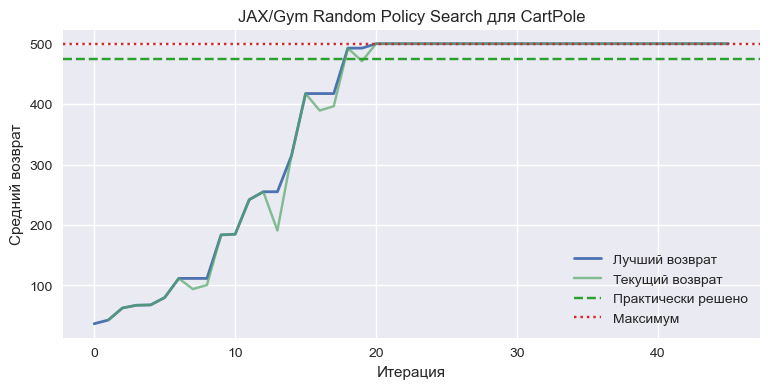

In [10]:
best_history = result["best_history"]
current_history = result["current_history"]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(best_history, label="Лучший возврат", linewidth=2)
ax.plot(np.arange(1, len(current_history) + 1), current_history, label="Текущий возврат", alpha=0.7)
ax.axhline(475, color="tab:green", linestyle="--", label="Практически решено")
ax.axhline(500, color="tab:red", linestyle=":", label="Максимум")
ax.set_xlabel("Итерация")
ax.set_ylabel("Средний возврат")
ax.set_title("JAX/Gym Random Policy Search для CartPole")
ax.legend()
plt.show()


## 6. Финальная проверка

Теперь проверим лучшую политику на новых эпизодах, которые не использовались в обучении.  
Это и есть основная метрика качества.


In [11]:
held_out_returns = rollout_batch(
    jnp.repeat(jnp.asarray(best_params, dtype=jnp.float32)[None, :], 50, axis=0),
    np.arange(50_000, 50_050),
)

summary = {
    "mean_return": float(np.mean(held_out_returns)),
    "std_return": float(np.std(held_out_returns)),
    "min_return": float(np.min(held_out_returns)),
    "max_return": float(np.max(held_out_returns)),
    "solved_rate_475+": float(np.mean(held_out_returns >= 475.0)),
}

for key, value in summary.items():
    print(f"{key}: {value:.3f}")

assert summary["mean_return"] >= 475.0, "Средний возврат слишком низкий: обучение стоит перепроверить."


mean_return: 496.900
std_return: 21.700
min_return: 345.000
max_return: 500.000
solved_rate_475+: 0.980


### Краткий вывод

Получился рабочий агент на `jax` и `gym`: он учится максимизировать суммарную награду и почти всегда удерживает шест до конца эпизода.  
Главная причина, почему решение работает быстро, — батчевый выбор действий в JAX и одновременная проверка многих политик через векторизованную среду Gym.
